In [ ]:
# ============================================================
# 1) Install dependencies
# ============================================================
!pip install -q aeon torch scikit-learn matplotlib numpy pandas

In [ ]:
# ============================================================
# 2) Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from aeon.datasets import load_classification
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

In [ ]:
# ============================================================
# 3) Global config
# ============================================================
CONFIG = {
    "target_length": 150,
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # choose backbone: "mlp" or "cnn1d"
    "backbone": "cnn1d",

    "hidden_dim": 64,
    "cnn_feature_dim": 64,
    "lr": 1e-3,
    "batch_size": 16,
    "epochs": 30,
    "ewc_lambda": 200.0,
    "lwf_alpha": 1.0,
    "lwf_temperature": 2.0,
    "replay_per_class": 30,
    "tsfd_alpha_logits": 1.0,
    "tsfd_alpha_features": 0.5,
    "tsfd_temperature": 2.0,
    "proto_memory_per_class": 20,
    "proto_alpha": 0.5,
    "val_ratio": 0.2,
}

SEQUENCES = [
    ["BasicMotions"],
    ["FaceDetection"],
    ["UWaveGestureLibrary"],
]

SEEDS = [0, 1, 2]

device = torch.device(CONFIG["device"])
print("Using device:", device)
print("Backbone:", CONFIG["backbone"])

Using device: cpu
Backbone: cnn1d


In [ ]:
# ============================================================
# 4) Utilities
# ============================================================
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def resize_1d_series(x, target_length):
    old_idx = np.linspace(0, 1, len(x))
    new_idx = np.linspace(0, 1, target_length)
    return np.interp(new_idx, old_idx, x).astype(np.float32)

def resize_multivariate_series(x, target_length):
    # x shape: (n_channels, length)
    return np.array([resize_1d_series(ch, target_length) for ch in x], dtype=np.float32)

def make_validation_split(X, y, val_ratio=0.2, seed=42):
    rng = np.random.RandomState(seed)
    indices = np.arange(len(X))
    rng.shuffle(indices)

    n_val = max(1, int(len(X) * val_ratio))
    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    if len(train_idx) == 0:
        train_idx = val_idx
        val_idx = indices[:1]

    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

def make_loader(X, y, batch_size=16, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

def accuracy(model, loader, device):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            targets.extend(yb.cpu().numpy())
    return accuracy_score(targets, preds)

In [ ]:
# ============================================================
# 5) Task abstraction
# ============================================================
@dataclass
class TimeSeriesTask:
    name: str
    X_train: np.ndarray
    y_train: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    X_val: np.ndarray = None
    y_val: np.ndarray = None
    local_num_classes: int = None
    global_class_ids: list = None

In [ ]:
# ============================================================
# 6) Global label-space builder
# ============================================================
class GlobalLabelSpace:
    """
    Builds a disjoint global class space across datasets/tasks.

    """
    def __init__(self):
        self.task_to_global = {}
        self.total_classes = 0

    def register_task(self, task_name, n_local_classes):
        if task_name in self.task_to_global:
            return self.task_to_global[task_name]

        global_ids = list(range(self.total_classes, self.total_classes + n_local_classes))
        self.task_to_global[task_name] = global_ids
        self.total_classes += n_local_classes
        return global_ids

    def map_labels(self, task_name, y_local):
        global_ids = self.task_to_global[task_name]
        return np.array([global_ids[int(y)] for y in y_local], dtype=np.int64)

In [ ]:
# ============================================================
# 7) Task loader with multivariate + multi-class support
# ============================================================
class AeonTaskLoader:
    def __init__(self, target_length=150, val_ratio=0.2, seed=42):
        self.target_length = target_length
        self.val_ratio = val_ratio
        self.seed = seed

    def load_raw_task(self, dataset_name):
        X_train, y_train = load_classification(dataset_name, split="train")
        X_test, y_test = load_classification(dataset_name, split="test")

        # Normalize shapes to (n_samples, n_channels, length)
        if X_train.ndim == 2:
            X_train = X_train[:, np.newaxis, :]
            X_test = X_test[:, np.newaxis, :]
        elif X_train.ndim != 3:
            raise ValueError(f"Unexpected shape for {dataset_name}: {X_train.shape}")

        # Resize all channels
        X_train = np.array([resize_multivariate_series(x, self.target_length) for x in X_train], dtype=np.float32)
        X_test = np.array([resize_multivariate_series(x, self.target_length) for x in X_test], dtype=np.float32)

        # Encode local labels
        le = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_test = le.transform(y_test)

        n_local_classes = len(np.unique(y_train))

        # Split train/val
        X_train_sub, y_train_sub, X_val, y_val = make_validation_split(
            X_train, y_train, val_ratio=self.val_ratio, seed=self.seed
        )

        # Channel-wise standardization
        n_channels = X_train.shape[1]
        scalers = []
        X_train_scaled = np.zeros_like(X_train_sub, dtype=np.float32)
        X_val_scaled = np.zeros_like(X_val, dtype=np.float32)
        X_test_scaled = np.zeros_like(X_test, dtype=np.float32)

        for ch in range(n_channels):
            scaler = StandardScaler()
            X_train_scaled[:, ch, :] = scaler.fit_transform(X_train_sub[:, ch, :]).astype(np.float32)
            X_val_scaled[:, ch, :] = scaler.transform(X_val[:, ch, :]).astype(np.float32)
            X_test_scaled[:, ch, :] = scaler.transform(X_test[:, ch, :]).astype(np.float32)
            scalers.append(scaler)

        return {
            "name": dataset_name,
            "X_train": X_train_scaled,
            "y_train_local": y_train_sub,
            "X_val": X_val_scaled,
            "y_val_local": y_val,
            "X_test": X_test_scaled,
            "y_test_local": y_test,
            "local_num_classes": n_local_classes,
            "n_channels": n_channels,
        }

    def load_sequence_raw(self, dataset_names):
        return [self.load_raw_task(name) for name in dataset_names]

In [ ]:
# ============================================================
# 8) Build tasks with shared global disjoint class space
# ============================================================
def build_task_sequence_with_global_labels(task_names, target_length=150, val_ratio=0.2, seed=42):
    loader = AeonTaskLoader(target_length=target_length, val_ratio=val_ratio, seed=seed)
    raw_tasks = loader.load_sequence_raw(task_names)

    # Validate equal channel count for current shared CNN setup
    n_channels_list = [raw["n_channels"] for raw in raw_tasks]
    if len(set(n_channels_list)) != 1:
        raise ValueError(
            f"Current shared CNN requires equal channel count across tasks. "
            f"Got: {dict(zip(task_names, n_channels_list))}"
        )

    global_space = GlobalLabelSpace()

    for raw in raw_tasks:
        global_space.register_task(raw["name"], raw["local_num_classes"])

    tasks = []
    for raw in raw_tasks:
        y_train_global = global_space.map_labels(raw["name"], raw["y_train_local"])
        y_val_global = global_space.map_labels(raw["name"], raw["y_val_local"])
        y_test_global = global_space.map_labels(raw["name"], raw["y_test_local"])

        task = TimeSeriesTask(
            name=raw["name"],
            X_train=raw["X_train"],
            y_train=y_train_global,
            X_test=raw["X_test"],
            y_test=y_test_global,
            X_val=raw["X_val"],
            y_val=y_val_global,
            local_num_classes=raw["local_num_classes"],
            global_class_ids=global_space.task_to_global[raw["name"]],
        )
        tasks.append(task)

    metadata = {
        "total_num_classes": global_space.total_classes,
        "task_to_global": global_space.task_to_global,
        "n_channels": raw_tasks[0]["n_channels"],
        "input_length": target_length,
    }

    return tasks, metadata

In [ ]:
# ============================================================
# 9) Models
# ============================================================
class FeatureMLP(nn.Module):
    def __init__(self, input_channels, input_length, hidden_dim=64, num_classes=2):
        super().__init__()
        self.input_dim = input_channels * input_length
        self.fc1 = nn.Linear(self.input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def _flatten(self, x):
        if x.ndim == 3:
            x = x.reshape(x.shape[0], -1)
        return x

    def extract_features(self, x):
        x = self._flatten(x)
        return self.relu(self.fc1(x))

    def forward(self, x):
        feats = self.extract_features(x)
        logits = self.fc2(feats)
        return logits


class FeatureCNN1D(nn.Module):
    """
    Multivariate 1D CNN.
    Input shape expected: (batch, channels, length)
    """
    def __init__(self, input_channels, input_length, num_classes=2, feature_dim=64):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(output_size=1)
        )

        self.feature_layer = nn.Linear(128, feature_dim)
        self.relu = nn.ReLU()
        self.classifier = nn.Linear(feature_dim, num_classes)

    def extract_features(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)

        h = self.conv_block(x)
        h = h.squeeze(-1)
        feats = self.relu(self.feature_layer(h))
        return feats

    def forward(self, x):
        feats = self.extract_features(x)
        logits = self.classifier(feats)
        return logits

In [ ]:
# ============================================================
# 10) Backbone factory
# ============================================================
def make_backbone(input_channels, input_length, num_classes):
    if CONFIG["backbone"] == "mlp":
        return FeatureMLP(
            input_channels=input_channels,
            input_length=input_length,
            hidden_dim=CONFIG["hidden_dim"],
            num_classes=num_classes
        )
    elif CONFIG["backbone"] == "cnn1d":
        return FeatureCNN1D(
            input_channels=input_channels,
            input_length=input_length,
            num_classes=num_classes,
            feature_dim=CONFIG["cnn_feature_dim"]
        )
    else:
        raise ValueError(f"Unknown backbone: {CONFIG['backbone']}")

In [ ]:
# ============================================================
# 11) Base strategy
# ============================================================
class BaseStrategy:
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30):
        self.model = model.to(device)
        self.device = device
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        self.ce_loss = nn.CrossEntropyLoss()

    def train_epoch(self, loader, extra_loss_fn=None):
        self.model.train()
        for xb, yb in loader:
            xb, yb = xb.to(self.device), yb.to(self.device)

            self.optimizer.zero_grad()
            logits = self.model(xb)
            loss = self.ce_loss(logits, yb)

            if extra_loss_fn is not None:
                extra = extra_loss_fn(xb, yb, logits)
                if isinstance(extra, (int, float)):
                    extra = torch.tensor(extra, dtype=torch.float32, device=self.device)
                loss = loss + extra

            loss.backward()
            self.optimizer.step()

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
        for _ in range(self.epochs):
            self.train_epoch(loader)

    def evaluate_task(self, task):
        loader = make_loader(task.X_test, task.y_test, batch_size=self.batch_size, shuffle=False)
        return accuracy(self.model, loader, self.device)

In [ ]:
# ============================================================
# 12) Baseline
# ============================================================
class BaselineStrategy(BaseStrategy):
    pass

In [ ]:
# ============================================================
# 13) EWC
# ============================================================
class EWCStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, ewc_lambda=200.0):
        super().__init__(model, device, lr, batch_size, epochs)
        self.ewc_lambda = ewc_lambda
        self.fisher = None
        self.old_params = None

    def compute_fisher(self, task):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
        fisher = {n: torch.zeros_like(p) for n, p in self.model.named_parameters()}

        self.model.eval()
        for xb, yb in loader:
            xb, yb = xb.to(self.device), yb.to(self.device)
            self.model.zero_grad()
            logits = self.model(xb)
            loss = self.ce_loss(logits, yb)
            loss.backward()

            for n, p in self.model.named_parameters():
                if p.grad is not None:
                    fisher[n] += p.grad.detach() ** 2

        for n in fisher:
            fisher[n] /= len(loader)

        return fisher

    def save_old_params(self):
        self.old_params = {n: p.detach().clone() for n, p in self.model.named_parameters()}

    def ewc_penalty(self):
        if self.fisher is None or self.old_params is None:
            return torch.tensor(0.0, device=self.device)

        penalty = torch.tensor(0.0, device=self.device)
        for n, p in self.model.named_parameters():
            penalty += (self.fisher[n] * (p - self.old_params[n]) ** 2).sum()
        return 0.5 * self.ewc_lambda * penalty

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.ewc_penalty()

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.fisher = self.compute_fisher(task)
        self.save_old_params()

In [ ]:
# ============================================================
# 14) LwF
# ============================================================
class LwFStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, alpha=1.0, temperature=2.0):
        super().__init__(model, device, lr, batch_size, epochs)
        self.alpha = alpha
        self.temperature = temperature
        self.teacher = None
        self.kl = nn.KLDivLoss(reduction="batchmean")

    def distillation_loss(self, xb, logits):
        if self.teacher is None:
            return torch.tensor(0.0, device=self.device)

        with torch.no_grad():
            teacher_logits = self.teacher(xb)

        student_log_probs = torch.log_softmax(logits / self.temperature, dim=1)
        teacher_probs = torch.softmax(teacher_logits / self.temperature, dim=1)
        return self.alpha * self.kl(student_log_probs, teacher_probs) * (self.temperature ** 2)

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.distillation_loss(xb, logits)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.teacher = deepcopy(self.model).to(self.device)
        self.teacher.eval()

In [ ]:
# ============================================================
# 15) Replay
# ============================================================
class ReplayStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30, replay_per_class=30):
        super().__init__(model, device, lr, batch_size, epochs)
        self.replay_per_class = replay_per_class
        self.memory_X = []
        self.memory_y = []

    def update_memory(self, X, y):
        mem_X, mem_y = [], []
        classes = np.unique(y)

        for c in classes:
            Xc = X[y == c]
            n = min(self.replay_per_class, len(Xc))
            idx = np.random.choice(len(Xc), size=n, replace=False)
            mem_X.append(Xc[idx])
            mem_y.append(np.full(n, c))

        mem_X = np.concatenate(mem_X, axis=0).astype(np.float32)
        mem_y = np.concatenate(mem_y).astype(np.int64)

        self.memory_X.append(mem_X)
        self.memory_y.append(mem_y)

    def get_memory(self):
        if len(self.memory_X) == 0:
            return None, None
        X_mem = np.concatenate(self.memory_X, axis=0).astype(np.float32)
        y_mem = np.concatenate(self.memory_y).astype(np.int64)
        return X_mem, y_mem

    def fit_task(self, task, task_id=None):
        if task_id == 0:
            loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)
            self.update_memory(task.X_train, task.y_train)
        else:
            X_mem, y_mem = self.get_memory()

            if X_mem is not None:
                X_mix = np.concatenate([task.X_train, X_mem], axis=0).astype(np.float32)
                y_mix = np.concatenate([task.y_train, y_mem]).astype(np.int64)
            else:
                X_mix, y_mix = task.X_train, task.y_train

            loader = make_loader(X_mix, y_mix, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)

            self.update_memory(task.X_train, task.y_train)

In [ ]:
# ============================================================
# 16) TS-FeatureDistill
# ============================================================
class TSFeatureDistillStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30,
                 alpha_logits=1.0, alpha_features=1.0, temperature=2.0):
        super().__init__(model, device, lr, batch_size, epochs)
        self.alpha_logits = alpha_logits
        self.alpha_features = alpha_features
        self.temperature = temperature
        self.teacher = None
        self.kl = nn.KLDivLoss(reduction="batchmean")
        self.mse = nn.MSELoss()

    def distill_loss(self, xb, logits):
        if self.teacher is None:
            return torch.tensor(0.0, device=self.device)

        with torch.no_grad():
            teacher_logits = self.teacher(xb)
            teacher_feats = self.teacher.extract_features(xb)

        student_log_probs = torch.log_softmax(logits / self.temperature, dim=1)
        teacher_probs = torch.softmax(teacher_logits / self.temperature, dim=1)
        logit_loss = self.kl(student_log_probs, teacher_probs) * (self.temperature ** 2)

        student_feats = self.model.extract_features(xb)
        feat_loss = self.mse(student_feats, teacher_feats)

        return self.alpha_logits * logit_loss + self.alpha_features * feat_loss

    def fit_task(self, task, task_id=None):
        loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)

        if task_id == 0:
            for _ in range(self.epochs):
                self.train_epoch(loader)
        else:
            def extra_loss_fn(xb, yb, logits):
                return self.distill_loss(xb, logits)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

        self.teacher = deepcopy(self.model).to(self.device)
        self.teacher.eval()

In [ ]:
# ============================================================
# 17) TS-ProtoReplay
# ============================================================
class TSProtoReplayStrategy(BaseStrategy):
    def __init__(self, model, device, lr=1e-3, batch_size=16, epochs=30,
                 memory_per_class=20, alpha_proto=1.0):
        super().__init__(model, device, lr, batch_size, epochs)
        self.memory_per_class = memory_per_class
        self.alpha_proto = alpha_proto
        self.memory_X = []
        self.memory_y = []
        self.prototypes = {}
        self.mse = nn.MSELoss()

    def update_memory(self, X, y):
        mem_X, mem_y = [], []
        classes = np.unique(y)

        for c in classes:
            Xc = X[y == c]
            n = min(self.memory_per_class, len(Xc))
            idx = np.random.choice(len(Xc), size=n, replace=False)
            mem_X.append(Xc[idx])
            mem_y.append(np.full(n, c))

        mem_X = np.concatenate(mem_X, axis=0).astype(np.float32)
        mem_y = np.concatenate(mem_y).astype(np.int64)

        self.memory_X.append(mem_X)
        self.memory_y.append(mem_y)

    def get_memory(self):
        if len(self.memory_X) == 0:
            return None, None
        X_mem = np.concatenate(self.memory_X, axis=0).astype(np.float32)
        y_mem = np.concatenate(self.memory_y).astype(np.int64)
        return X_mem, y_mem

    def update_prototypes(self):
        X_mem, y_mem = self.get_memory()
        if X_mem is None:
            return

        self.model.eval()
        X_t = torch.tensor(X_mem, dtype=torch.float32).to(self.device)
        y_t = torch.tensor(y_mem, dtype=torch.long).to(self.device)

        with torch.no_grad():
            feats = self.model.extract_features(X_t)

        self.prototypes = {}
        for c in torch.unique(y_t):
            mask = y_t == c
            proto = feats[mask].mean(dim=0)
            self.prototypes[int(c.item())] = proto.detach().clone()

    def prototype_loss(self, xb, yb):
        if len(self.prototypes) == 0:
            return torch.tensor(0.0, device=self.device)

        feats = self.model.extract_features(xb)
        loss = torch.tensor(0.0, device=self.device)
        count = 0

        for c, proto in self.prototypes.items():
            mask = (yb == c)
            if mask.sum() > 0:
                loss += self.mse(feats[mask].mean(dim=0), proto.to(self.device))
                count += 1

        if count == 0:
            return torch.tensor(0.0, device=self.device)
        return self.alpha_proto * loss / count

    def fit_task(self, task, task_id=None):
        if task_id == 0:
            loader = make_loader(task.X_train, task.y_train, batch_size=self.batch_size, shuffle=True)
            for _ in range(self.epochs):
                self.train_epoch(loader)

            self.update_memory(task.X_train, task.y_train)
            self.update_prototypes()
        else:
            X_mem, y_mem = self.get_memory()

            if X_mem is not None:
                X_mix = np.concatenate([task.X_train, X_mem], axis=0).astype(np.float32)
                y_mix = np.concatenate([task.y_train, y_mem]).astype(np.int64)
            else:
                X_mix, y_mix = task.X_train, task.y_train

            loader = make_loader(X_mix, y_mix, batch_size=self.batch_size, shuffle=True)

            def extra_loss_fn(xb, yb, logits):
                return self.prototype_loss(xb, yb)

            for _ in range(self.epochs):
                self.train_epoch(loader, extra_loss_fn=extra_loss_fn)

            self.update_memory(task.X_train, task.y_train)
            self.update_prototypes()

In [ ]:
# ============================================================
# 18) Strategy factory
# ============================================================
def make_strategies(input_channels, input_length, num_classes, device):
    def backbone():
        return make_backbone(input_channels, input_length, num_classes)

    return {
        "Baseline": BaselineStrategy(
            model=backbone(), device=device,
            lr=CONFIG["lr"], batch_size=CONFIG["batch_size"], epochs=CONFIG["epochs"]
        ),
        "EWC": EWCStrategy(
            model=backbone(), device=device,
            lr=CONFIG["lr"], batch_size=CONFIG["batch_size"], epochs=CONFIG["epochs"],
            ewc_lambda=CONFIG["ewc_lambda"]
        ),
        "LwF": LwFStrategy(
            model=backbone(), device=device,
            lr=CONFIG["lr"], batch_size=CONFIG["batch_size"], epochs=CONFIG["epochs"],
            alpha=CONFIG["lwf_alpha"], temperature=CONFIG["lwf_temperature"]
        ),
        "Replay": ReplayStrategy(
            model=backbone(), device=device,
            lr=CONFIG["lr"], batch_size=CONFIG["batch_size"], epochs=CONFIG["epochs"],
            replay_per_class=CONFIG["replay_per_class"]
        ),
        "TS-FeatureDistill": TSFeatureDistillStrategy(
            model=backbone(), device=device,
            lr=CONFIG["lr"], batch_size=CONFIG["batch_size"], epochs=CONFIG["epochs"],
            alpha_logits=CONFIG["tsfd_alpha_logits"],
            alpha_features=CONFIG["tsfd_alpha_features"],
            temperature=CONFIG["tsfd_temperature"]
        ),
        "TS-ProtoReplay": TSProtoReplayStrategy(
            model=backbone(), device=device,
            lr=CONFIG["lr"], batch_size=CONFIG["batch_size"], epochs=CONFIG["epochs"],
            memory_per_class=CONFIG["proto_memory_per_class"],
            alpha_proto=CONFIG["proto_alpha"]
        ),
    }

In [ ]:
# ============================================================
# 19) Metrics
# ============================================================
def final_average_accuracy(acc_matrix):
    last_row = acc_matrix[-1]
    valid = last_row[last_row > 0]
    return valid.mean() if len(valid) > 0 else 0.0

def final_forgetting(acc_matrix):
    n_tasks = acc_matrix.shape[1]
    forgetting = []

    for t in range(n_tasks - 1):
        best_before = np.max(acc_matrix[:, t])
        final_acc = acc_matrix[-1, t]
        forgetting.append(best_before - final_acc)

    return np.mean(forgetting) if len(forgetting) > 0 else 0.0

def per_task_final_accuracy(acc_matrix):
    return acc_matrix[-1, :]

def backward_transfer(acc_matrix):
    n_tasks = acc_matrix.shape[0]
    bwt_vals = []

    for t in range(n_tasks - 1):
        final_acc = acc_matrix[-1, t]
        learned_acc = acc_matrix[t, t]
        bwt_vals.append(final_acc - learned_acc)

    return np.mean(bwt_vals) if len(bwt_vals) > 0 else 0.0

In [ ]:
# ============================================================
# 20) Experiment runner
# ============================================================
class ContinualLearningExperiment:
    def __init__(self, tasks, strategy_dict):
        self.tasks = tasks
        self.strategy_dict = strategy_dict
        self.results = {}

    def run(self):
        n_tasks = len(self.tasks)

        for name in self.strategy_dict.keys():
            self.results[name] = np.zeros((n_tasks, n_tasks))

        for task_id, task in enumerate(self.tasks):
            print(f"\n==============================")
            print(f"Training phase: Task {task_id+1} / {n_tasks} -> {task.name}")
            print(f"Global classes for this task: {task.global_class_ids}")
            print(f"==============================")

            for name, strategy in self.strategy_dict.items():
                print(f"\nRunning strategy: {name}")
                strategy.fit_task(task, task_id=task_id)

                for eval_id in range(task_id + 1):
                    acc = strategy.evaluate_task(self.tasks[eval_id])
                    self.results[name][task_id, eval_id] = acc
                    print(f"  Eval on task {eval_id+1} ({self.tasks[eval_id].name}): {acc:.4f}")

        return self.results

    def summary(self):
        rows = []
        for name, acc_matrix in self.results.items():
            row = {
                "method": name,
                "final_avg_acc": final_average_accuracy(acc_matrix),
                "final_forgetting": final_forgetting(acc_matrix),
                "backward_transfer": backward_transfer(acc_matrix),
            }

            final_task_accs = per_task_final_accuracy(acc_matrix)
            for i, acc in enumerate(final_task_accs):
                row[f"final_task{i+1}_acc"] = acc

            rows.append(row)

        return pd.DataFrame(rows)

In [ ]:
# ============================================================
# 21) Single run
# ============================================================
def run_one_sequence_one_seed(task_names, seed, device, target_length=150, verbose=True):
    set_seed(seed)

    tasks, metadata = build_task_sequence_with_global_labels(
        task_names,
        target_length=target_length,
        val_ratio=CONFIG["val_ratio"],
        seed=seed
    )

    input_channels = metadata["n_channels"]
    input_length = metadata["input_length"]
    num_classes = metadata["total_num_classes"]

    print("Metadata:", metadata)
    for i, task in enumerate(tasks):
        print(f"Task {i+1}: {task.name}")
        print("  X_train shape:", task.X_train.shape)
        print("  X_test shape :", task.X_test.shape)
        print("  local/global classes:", task.local_num_classes, task.global_class_ids)

    strategies = make_strategies(input_channels, input_length, num_classes, device)

    experiment = ContinualLearningExperiment(tasks, strategies)
    experiment.run()
    summary_df = experiment.summary()

    sequence_name = " -> ".join(task_names)
    summary_df["sequence"] = sequence_name
    summary_df["seed"] = seed

    matrices = {}
    for method, acc_matrix in experiment.results.items():
        matrices[method] = acc_matrix.copy()

    if verbose:
        print(f"\nFinished sequence: {sequence_name}, seed: {seed}")
        display(summary_df)

    return {
        "sequence": sequence_name,
        "seed": seed,
        "summary": summary_df,
        "matrices": matrices,
        "task_names": task_names,
        "metadata": metadata,
    }

In [ ]:
# ============================================================
# 22) Full benchmark runner
# ============================================================
def run_benchmark(sequences, seeds, device, target_length=150, verbose=False):
    all_runs = []

    for seq in sequences:
        for seed in seeds:
            print("\n############################################")
            print(f"Running sequence {seq} with seed {seed}")
            print("############################################")

            run_data = run_one_sequence_one_seed(
                task_names=seq,
                seed=seed,
                device=device,
                target_length=target_length,
                verbose=verbose
            )
            all_runs.append(run_data)

    return all_runs

In [ ]:
# ============================================================
# 23) Aggregation helpers
# ============================================================
def aggregate_results(all_runs):
    all_summaries = []
    for run in all_runs:
        all_summaries.append(run["summary"])

    full_df = pd.concat(all_summaries, ignore_index=True)

    metric_cols = [
        "final_avg_acc",
        "final_forgetting",
        "backward_transfer",
    ]

    final_task_cols = [c for c in full_df.columns if c.startswith("final_task") and c.endswith("_acc")]
    metric_cols.extend(final_task_cols)

    agg_dict = {}
    for col in metric_cols:
        agg_dict[f"{col}_mean"] = (col, "mean")
        agg_dict[f"{col}_std"] = (col, "std")

    agg_df = (
        full_df.groupby(["sequence", "method"])
        .agg(**agg_dict)
        .reset_index()
    )

    return full_df, agg_df

In [ ]:
# ============================================================
# 24) Plotting
# ============================================================
def plot_sequence_results(agg_df, metric="final_avg_acc_mean"):
    sequences = agg_df["sequence"].unique()

    for seq in sequences:
        sub = agg_df[agg_df["sequence"] == seq].copy()

        if metric == "final_avg_acc_mean":
            y = sub["final_avg_acc_mean"].values
            yerr = sub["final_avg_acc_std"].fillna(0).values
            title = f"Final Average Accuracy: {seq}"
            ylabel = "Final Average Accuracy"
        elif metric == "final_forgetting_mean":
            y = sub["final_forgetting_mean"].values
            yerr = sub["final_forgetting_std"].fillna(0).values
            title = f"Final Forgetting: {seq}"
            ylabel = "Final Forgetting"
        elif metric == "backward_transfer_mean":
            y = sub["backward_transfer_mean"].values
            yerr = sub["backward_transfer_std"].fillna(0).values
            title = f"Backward Transfer: {seq}"
            ylabel = "Backward Transfer"
        else:
            raise ValueError("Unsupported metric")

        plt.figure(figsize=(11, 4))
        plt.bar(sub["method"], y, yerr=yerr, capsize=4)
        plt.xticks(rotation=45)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.show()

In [ ]:
# ============================================================
# 25) Run benchmark
# ============================================================
all_runs = run_benchmark(
    sequences=SEQUENCES,
    seeds=SEEDS,
    device=device,
    target_length=CONFIG["target_length"],
    verbose=False
)


############################################
Running sequence ['BasicMotions'] with seed 0
############################################
Metadata: {'total_num_classes': 4, 'task_to_global': {'BasicMotions': [0, 1, 2, 3]}, 'n_channels': 6, 'input_length': 150}
Task 1: BasicMotions
  X_train shape: (32, 6, 150)
  X_test shape : (40, 6, 150)
  local/global classes: 4 [0, 1, 2, 3]


/tmp/ipykernel_13059/3843054481.py:11: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_13059/3843054481.py:12: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")



Training phase: Task 1 / 1 -> BasicMotions
Global classes for this task: [0, 1, 2, 3]

Running strategy: Baseline
  Eval on task 1 (BasicMotions): 0.9500

Running strategy: EWC
  Eval on task 1 (BasicMotions): 0.9500

Running strategy: LwF
  Eval on task 1 (BasicMotions): 0.9750

Running strategy: Replay
  Eval on task 1 (BasicMotions): 1.0000

Running strategy: TS-FeatureDistill
  Eval on task 1 (BasicMotions): 0.9500

Running strategy: TS-ProtoReplay
  Eval on task 1 (BasicMotions): 1.0000

############################################
Running sequence ['BasicMotions'] with seed 1
############################################
Metadata: {'total_num_classes': 4, 'task_to_global': {'BasicMotions': [0, 1, 2, 3]}, 'n_channels': 6, 'input_length': 150}
Task 1: BasicMotions
  X_train shape: (32, 6, 150)
  X_test shape : (40, 6, 150)
  local/global classes: 4 [0, 1, 2, 3]

Training phase: Task 1 / 1 -> BasicMotions
Global classes for this task: [0, 1, 2, 3]

Running strategy: Baseline


/tmp/ipykernel_13059/3843054481.py:11: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_13059/3843054481.py:12: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")


  Eval on task 1 (BasicMotions): 0.9500

Running strategy: EWC
  Eval on task 1 (BasicMotions): 0.9750

Running strategy: LwF
  Eval on task 1 (BasicMotions): 0.9750

Running strategy: Replay
  Eval on task 1 (BasicMotions): 0.9500

Running strategy: TS-FeatureDistill
  Eval on task 1 (BasicMotions): 0.9750

Running strategy: TS-ProtoReplay
  Eval on task 1 (BasicMotions): 0.9500

############################################
Running sequence ['BasicMotions'] with seed 2
############################################
Metadata: {'total_num_classes': 4, 'task_to_global': {'BasicMotions': [0, 1, 2, 3]}, 'n_channels': 6, 'input_length': 150}
Task 1: BasicMotions
  X_train shape: (32, 6, 150)
  X_test shape : (40, 6, 150)
  local/global classes: 4 [0, 1, 2, 3]

Training phase: Task 1 / 1 -> BasicMotions
Global classes for this task: [0, 1, 2, 3]

Running strategy: Baseline


...

Metadata: {'total_num_classes': 8, 'task_to_global': {'UWaveGestureLibrary': [0, 1, 2, 3, 4, 5, 6, 7]}, 'n_channels': 3, 'input_length': 150}
Task 1: UWaveGestureLibrary
  X_train shape: (96, 3, 150)
  X_test shape : (320, 3, 150)
  local/global classes: 8 [0, 1, 2, 3, 4, 5, 6, 7]

Training phase: Task 1 / 1 -> UWaveGestureLibrary
Global classes for this task: [0, 1, 2, 3, 4, 5, 6, 7]

Running strategy: Baseline
  Eval on task 1 (UWaveGestureLibrary): 0.5813

Running strategy: EWC
  Eval on task 1 (UWaveGestureLibrary): 0.6594

Running strategy: LwF
  Eval on task 1 (UWaveGestureLibrary): 0.6500

Running strategy: Replay
  Eval on task 1 (UWaveGestureLibrary): 0.6188

Running strategy: TS-FeatureDistill
  Eval on task 1 (UWaveGestureLibrary): 0.6531

Running strategy: TS-ProtoReplay
  Eval on task 1 (UWaveGestureLibrary): 0.6500

############################################
Running sequence ['UWaveGestureLibrary'] with seed 1
############################################
Metadata: {'tot

/tmp/ipykernel_13059/3843054481.py:11: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_13059/3843054481.py:12: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")


  Eval on task 1 (UWaveGestureLibrary): 0.6344

Running strategy: EWC
  Eval on task 1 (UWaveGestureLibrary): 0.6188

Running strategy: LwF
  Eval on task 1 (UWaveGestureLibrary): 0.6375

Running strategy: Replay
  Eval on task 1 (UWaveGestureLibrary): 0.6250

Running strategy: TS-FeatureDistill
  Eval on task 1 (UWaveGestureLibrary): 0.6656

Running strategy: TS-ProtoReplay
  Eval on task 1 (UWaveGestureLibrary): 0.5875

############################################
Running sequence ['UWaveGestureLibrary'] with seed 2
############################################
Metadata: {'total_num_classes': 8, 'task_to_global': {'UWaveGestureLibrary': [0, 1, 2, 3, 4, 5, 6, 7]}, 'n_channels': 3, 'input_length': 150}
Task 1: UWaveGestureLibrary
  X_train shape: (96, 3, 150)
  X_test shape : (320, 3, 150)
  local/global classes: 8 [0, 1, 2, 3, 4, 5, 6, 7]

Training phase: Task 1 / 1 -> UWaveGestureLibrary
Global classes for this task: [0, 1, 2, 3, 4, 5, 6, 7]

Running strategy: Baseline


/tmp/ipykernel_13059/3843054481.py:11: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_13059/3843054481.py:12: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")


  Eval on task 1 (UWaveGestureLibrary): 0.5938

Running strategy: EWC
  Eval on task 1 (UWaveGestureLibrary): 0.5969

Running strategy: LwF
  Eval on task 1 (UWaveGestureLibrary): 0.6188

Running strategy: Replay
  Eval on task 1 (UWaveGestureLibrary): 0.5781

Running strategy: TS-FeatureDistill
  Eval on task 1 (UWaveGestureLibrary): 0.5687

Running strategy: TS-ProtoReplay
  Eval on task 1 (UWaveGestureLibrary): 0.6969


In [ ]:
# ============================================================
# 26) Aggregate and display results
# ============================================================
full_df, agg_df = aggregate_results(all_runs)

print("\n=== Per-run summary ===")
display(full_df)

print("\n=== Mean / Std summary ===")
display(agg_df)


=== Per-run summary ===


,method,final_avg_acc,final_forgetting,backward_transfer,final_task1_acc,sequence,seed
0,Baseline,0.950000,0.0,0.0,0.950000,BasicMotions,0
1,EWC,0.950000,0.0,0.0,0.950000,BasicMotions,0
2,LwF,0.975000,0.0,0.0,0.975000,BasicMotions,0
3,Replay,1.000000,0.0,0.0,1.000000,BasicMotions,0
4,TS-FeatureDistill,0.950000,0.0,0.0,0.950000,BasicMotions,0
5,TS-ProtoReplay,1.000000,0.0,0.0,1.000000,BasicMotions,0
6,Baseline,0.950000,0.0,0.0,0.950000,BasicMotions,1
7,EWC,0.975000,0.0,0.0,0.975000,BasicMotions,1
8,LwF,0.975000,0.0,0.0,0.975000,BasicMotions,1
9,Replay,0.950000,0.0,0.0,0.950000,BasicMotions,1



=== Mean / Std summary ===


,sequence,method,final_avg_acc_mean,final_avg_acc_std,final_forgetting_mean,final_forgetting_std,backward_transfer_mean,backward_transfer_std,final_task1_acc_mean,final_task1_acc_std
0,BasicMotions,Baseline,0.958333,0.014434,0.0,0.0,0.0,0.0,0.958333,0.014434
1,BasicMotions,EWC,0.975000,0.025000,0.0,0.0,0.0,0.0,0.975000,0.025000
2,BasicMotions,LwF,0.975000,0.000000,0.0,0.0,0.0,0.0,0.975000,0.000000
3,BasicMotions,Replay,0.975000,0.025000,0.0,0.0,0.0,0.0,0.975000,0.025000
4,BasicMotions,TS-FeatureDistill,0.975000,0.025000,0.0,0.0,0.0,0.0,0.975000,0.025000
5,BasicMotions,TS-ProtoReplay,0.975000,0.025000,0.0,0.0,0.0,0.0,0.975000,0.025000
6,FaceDetection,Baseline,0.530174,0.005402,0.0,0.0,0.0,0.0,0.530174,0.005402
7,FaceDetection,EWC,0.532160,0.008581,0.0,0.0,0.0,0.0,0.532160,0.008581
8,FaceDetection,LwF,0.541525,0.007690,0.0,0.0,0.0,0.0,0.541525,0.007690
9,FaceDetection,Replay,0.526485,0.007102,0.0,0.0,0.0,0.0,0.526485,0.007102


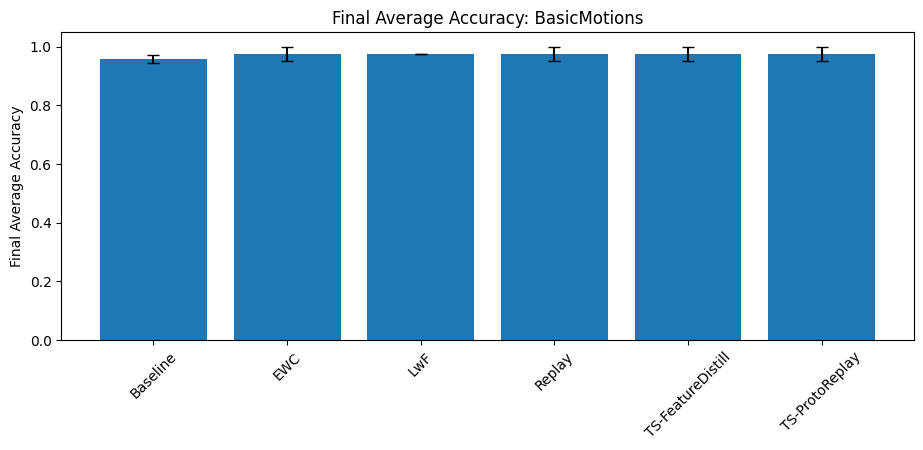

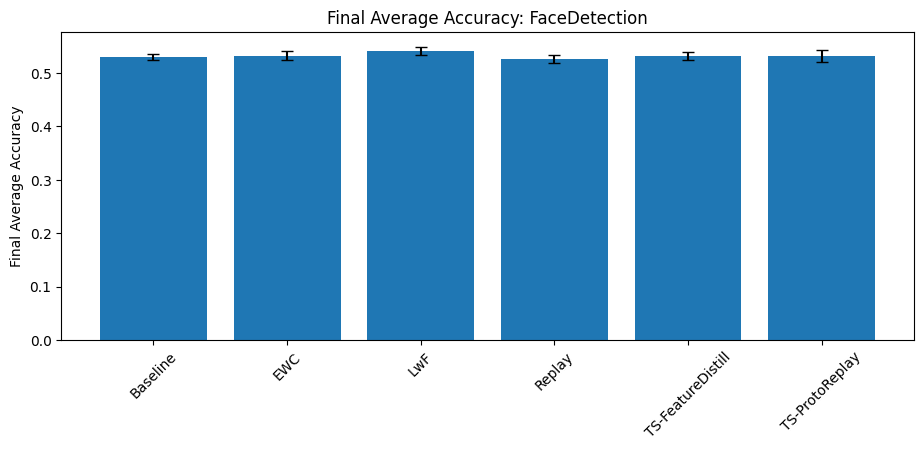

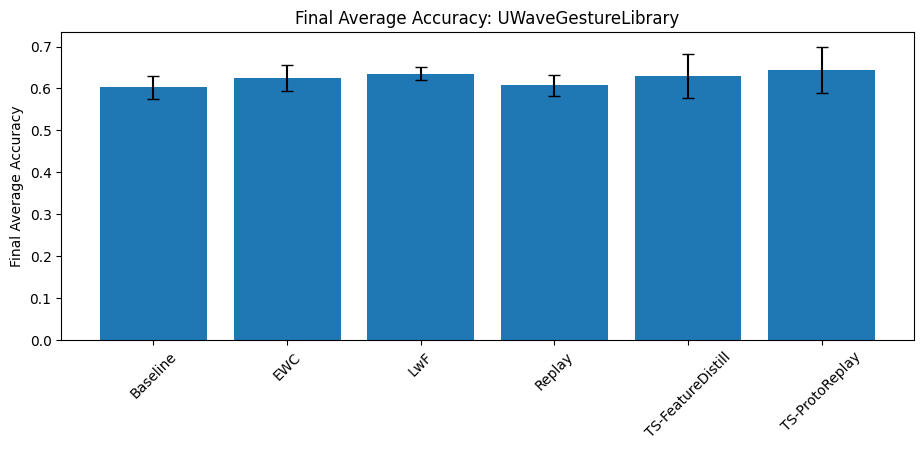

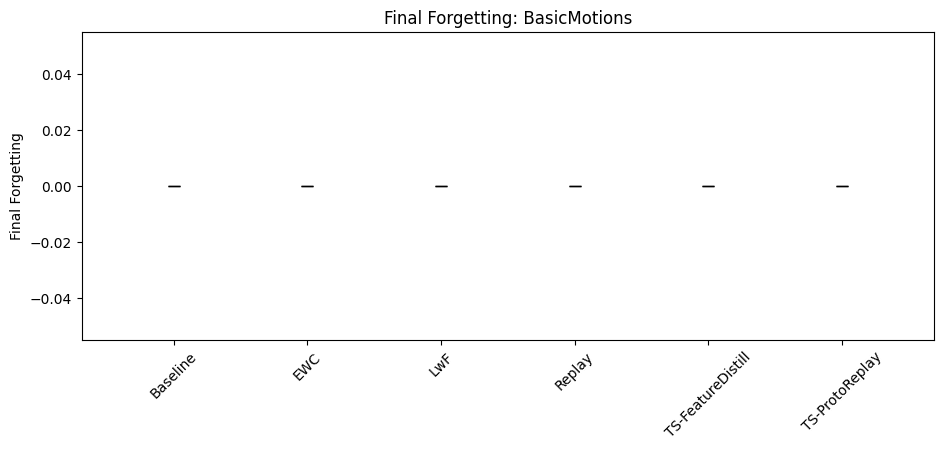

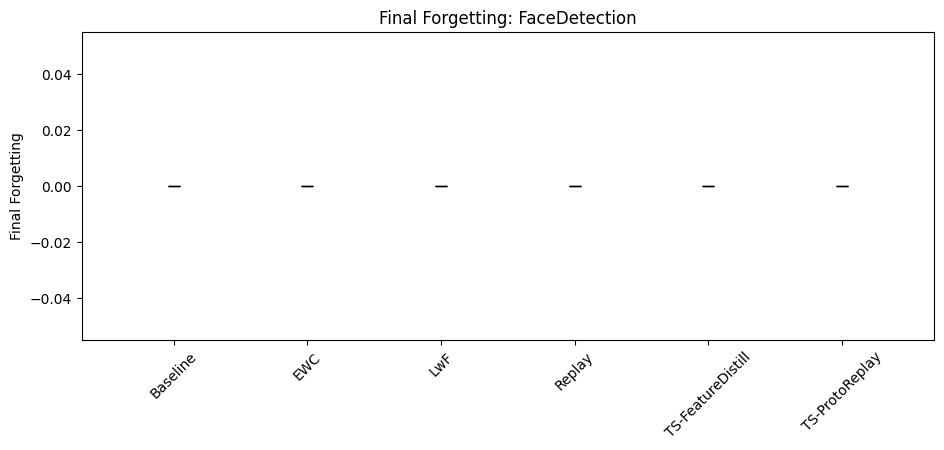

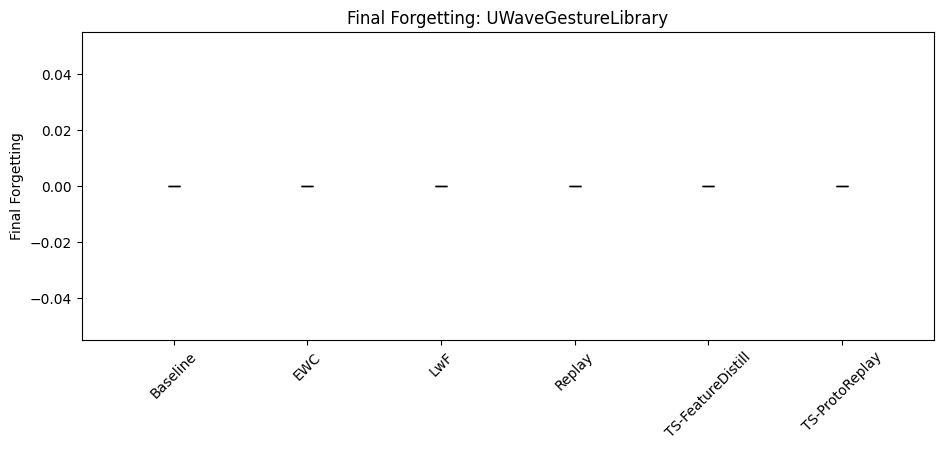

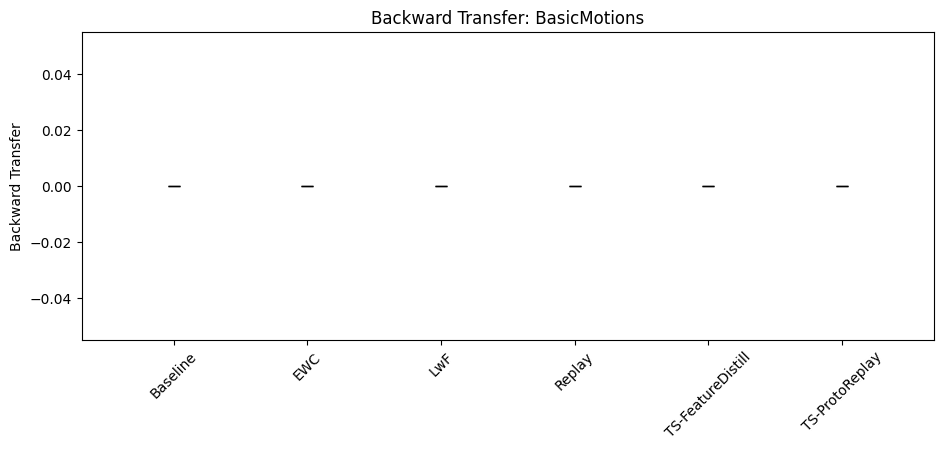

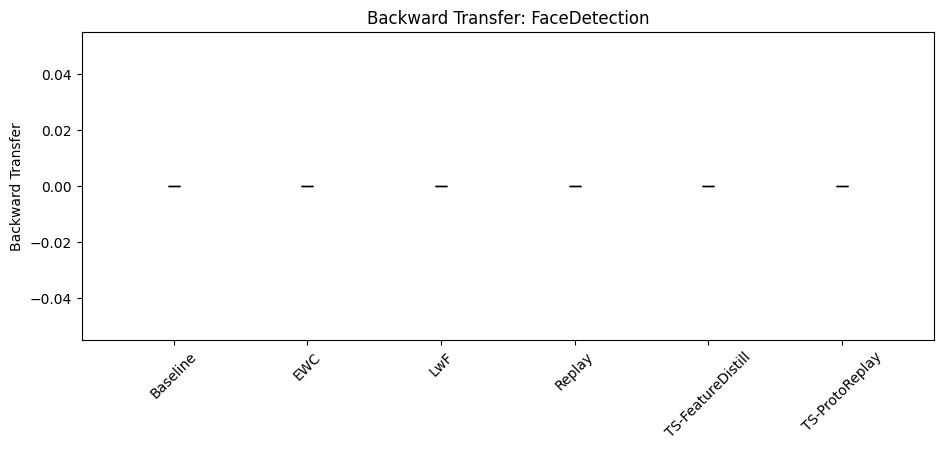

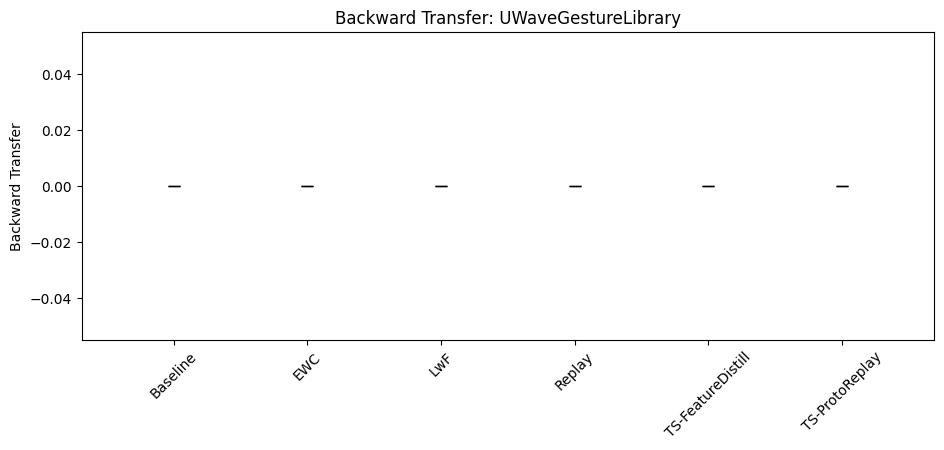

In [ ]:
# ============================================================
# 27) Plot results
# ============================================================
plot_sequence_results(agg_df, metric="final_avg_acc_mean")
plot_sequence_results(agg_df, metric="final_forgetting_mean")
plot_sequence_results(agg_df, metric="backward_transfer_mean")

In [ ]:
# ============================================================
# 28) Visualize multivariate sample with true/predicted class
# ============================================================
def visualize_multivariate_prediction(strategy, task, sample_idx=0, class_id_to_name=None):
    """
    Visualize one multivariate time series sample and show:
    - true class
    - predicted class

    strategy: trained strategy object (e.g. Baseline, EWC, etc.)
    task: TimeSeriesTask
    sample_idx: index in task.X_test
    class_id_to_name: optional dict {global_class_id: readable_name}
    """
    X = task.X_test[sample_idx]   # shape: (channels, length)
    y_true = int(task.y_test[sample_idx])

    x_tensor = torch.tensor(X[np.newaxis, ...], dtype=torch.float32).to(strategy.device)

    strategy.model.eval()
    with torch.no_grad():
        logits = strategy.model(x_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        y_pred = int(np.argmax(probs))
        conf = float(np.max(probs))

    n_channels, seq_len = X.shape
    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 2.2 * n_channels), sharex=True)

    if n_channels == 1:
        axes = [axes]

    for ch in range(n_channels):
        axes[ch].plot(np.arange(seq_len), X[ch], label=f"Channel {ch}", linewidth=1.5)
        axes[ch].legend(loc="upper right")
        axes[ch].grid(True, alpha=0.3)

    true_name = class_id_to_name[y_true] if class_id_to_name and y_true in class_id_to_name else str(y_true)
    pred_name = class_id_to_name[y_pred] if class_id_to_name and y_pred in class_id_to_name else str(y_pred)

    plt.suptitle(
        f"Task: {task.name} | Sample {sample_idx}\n"
        f"True class: {true_name} | Predicted class: {pred_name} | Confidence: {conf:.3f}",
        fontsize=12
    )
    plt.xlabel("Time")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [ ]:
# ============================================================
# 29) Build readable class-name mapping for one task
# ============================================================
def build_task_class_name_map(task):
    """
    For now, map each global class id to a readable string.
    Example: global 0 -> 'BasicMotions_class_0'
    """
    mapping = {}
    for local_idx, global_id in enumerate(task.global_class_ids):
        mapping[int(global_id)] = f"{task.name}_class_{local_idx}"
    return mapping

/tmp/ipykernel_13059/3843054481.py:11: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_train, y_train = load_classification(dataset_name, split="train")
/tmp/ipykernel_13059/3843054481.py:12: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_test, y_test = load_classification(dataset_name, split="test")


Task name: BasicMotions
X_test shape: (40, 6, 150)
Global class ids: [0, 1, 2, 3]


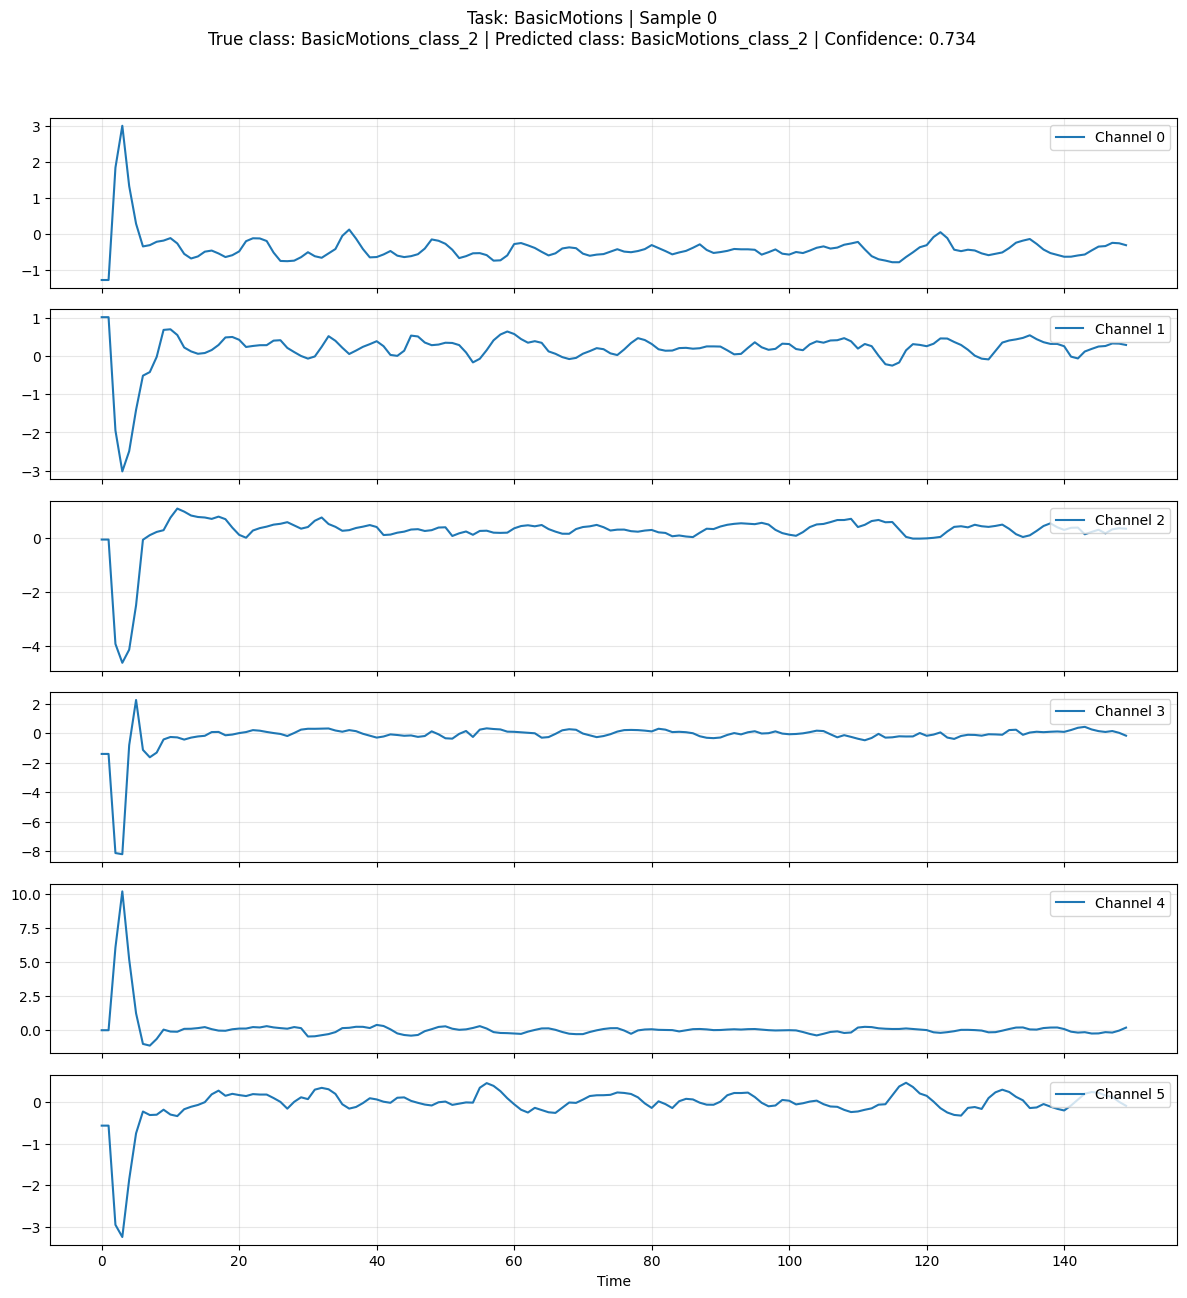

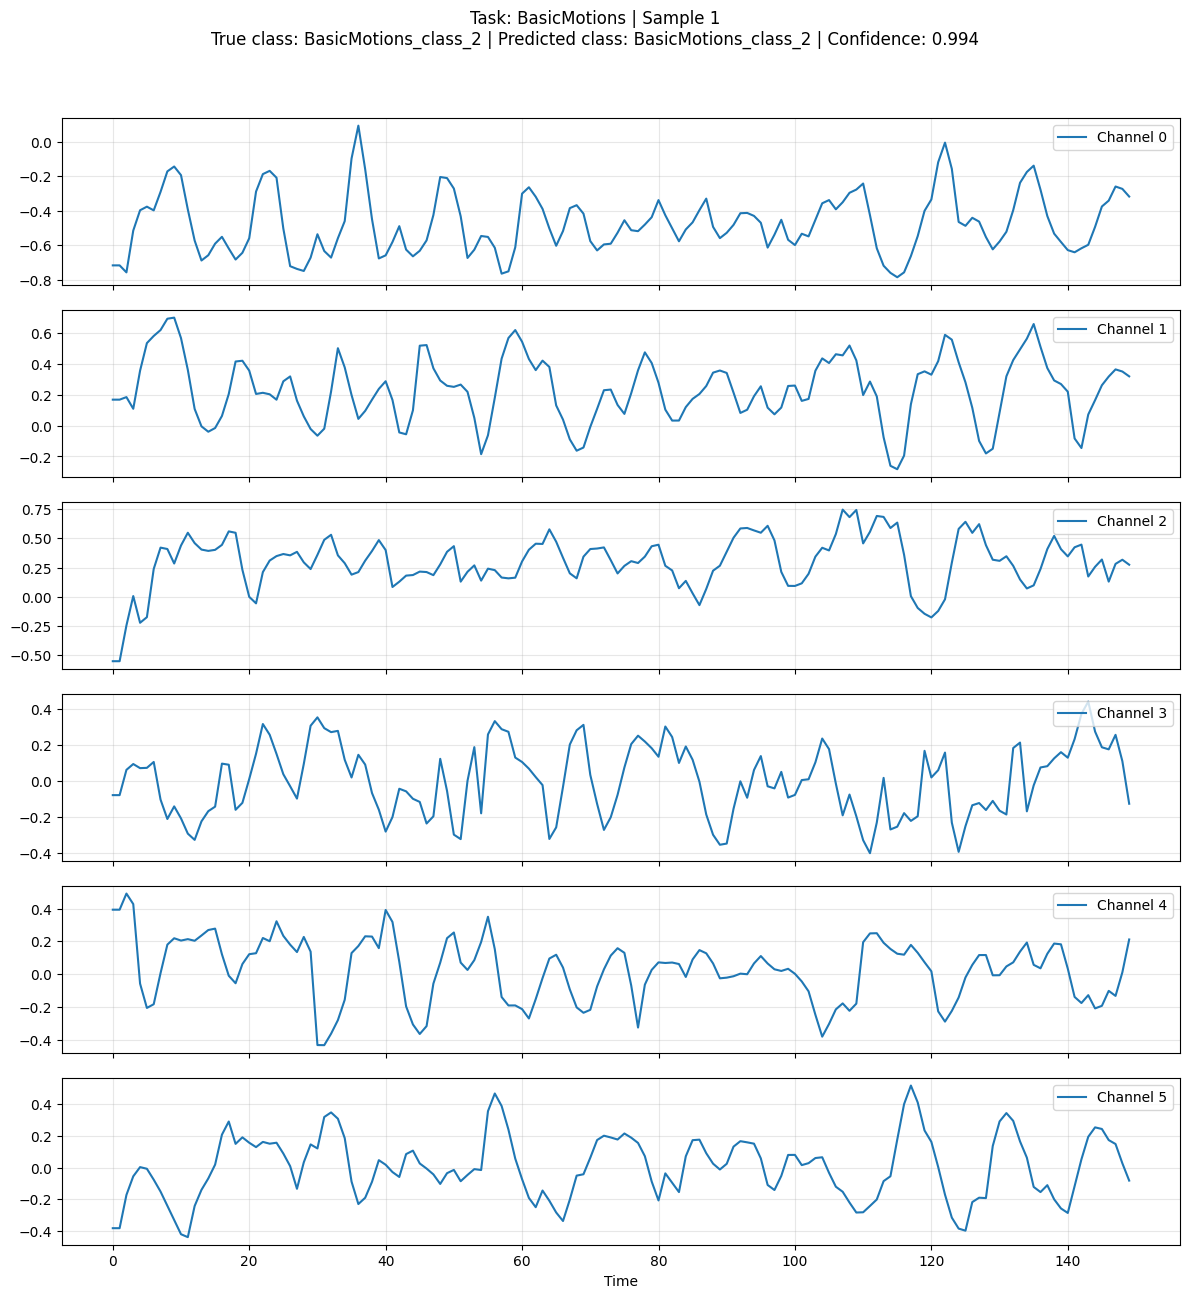

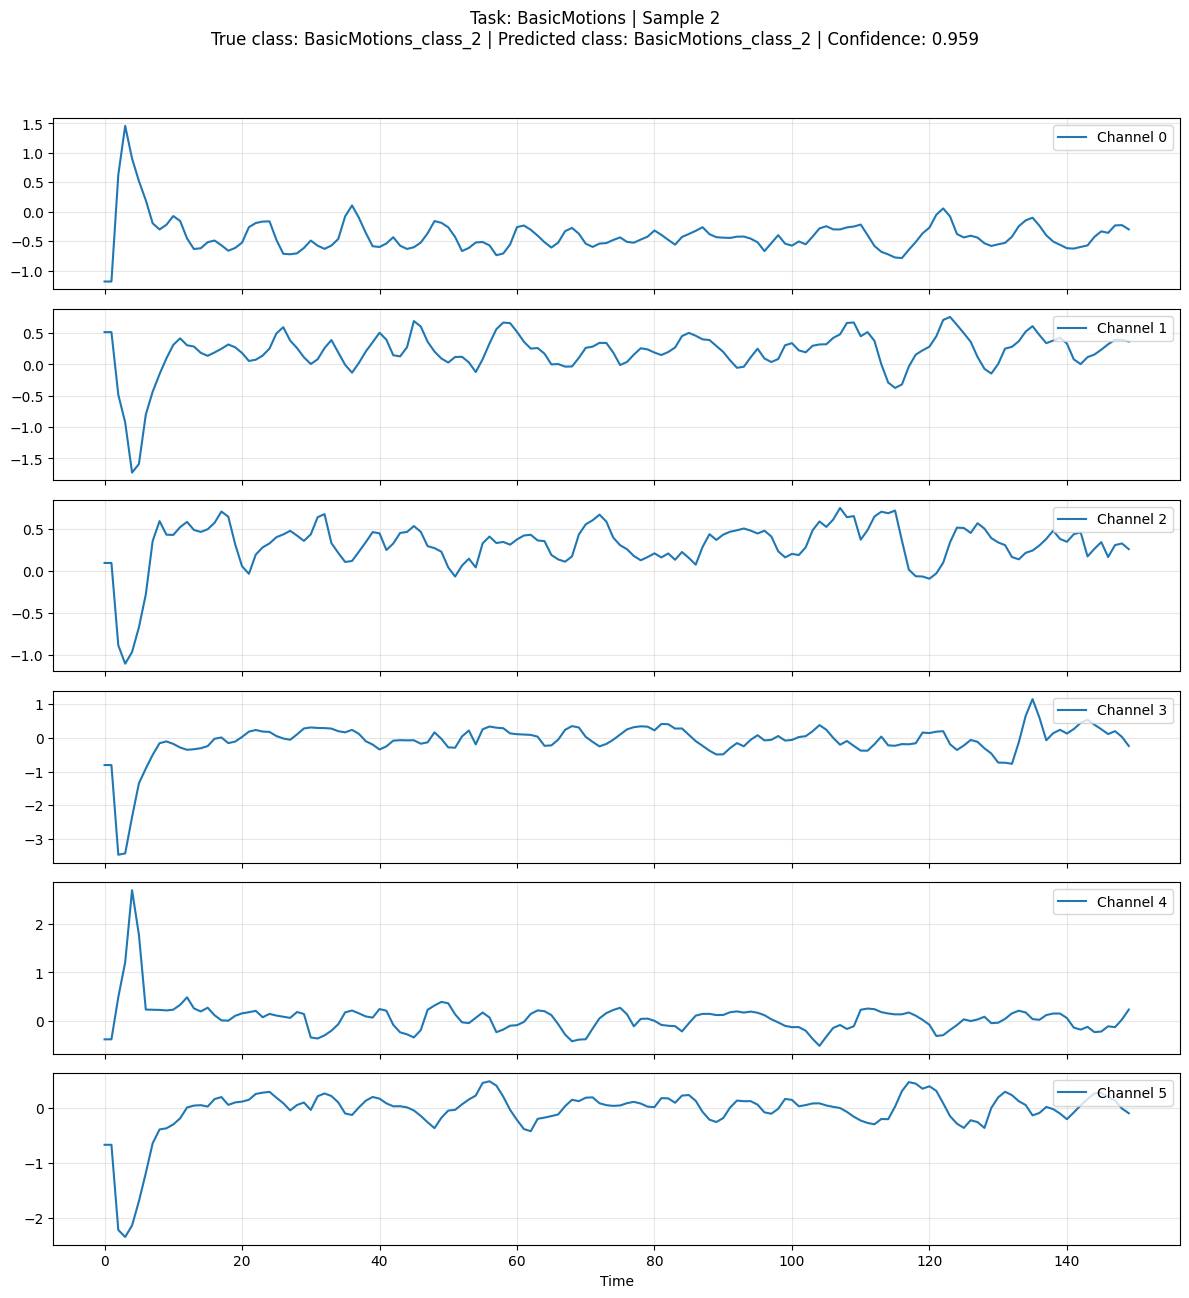

In [ ]:
# ============================================================
# 30) Train one sequence and visualize predictions
# ============================================================
seed = 0
task_names = ["BasicMotions"]   # start with one task first for debugging

tasks, metadata = build_task_sequence_with_global_labels(
    task_names,
    target_length=CONFIG["target_length"],
    val_ratio=CONFIG["val_ratio"],
    seed=seed
)

input_channels = metadata["n_channels"]
input_length = metadata["input_length"]
num_classes = metadata["total_num_classes"]

strategies = make_strategies(input_channels, input_length, num_classes, device)

# train only one method for quick demo
baseline = strategies["Baseline"]
baseline.fit_task(tasks[0], task_id=0)

print("Task name:", tasks[0].name)
print("X_test shape:", tasks[0].X_test.shape)
print("Global class ids:", tasks[0].global_class_ids)

class_map = build_task_class_name_map(tasks[0])

# visualize a few predictions
visualize_multivariate_prediction(baseline, tasks[0], sample_idx=0, class_id_to_name=class_map)
visualize_multivariate_prediction(baseline, tasks[0], sample_idx=1, class_id_to_name=class_map)
visualize_multivariate_prediction(baseline, tasks[0], sample_idx=2, class_id_to_name=class_map)

First misclassified index: 20


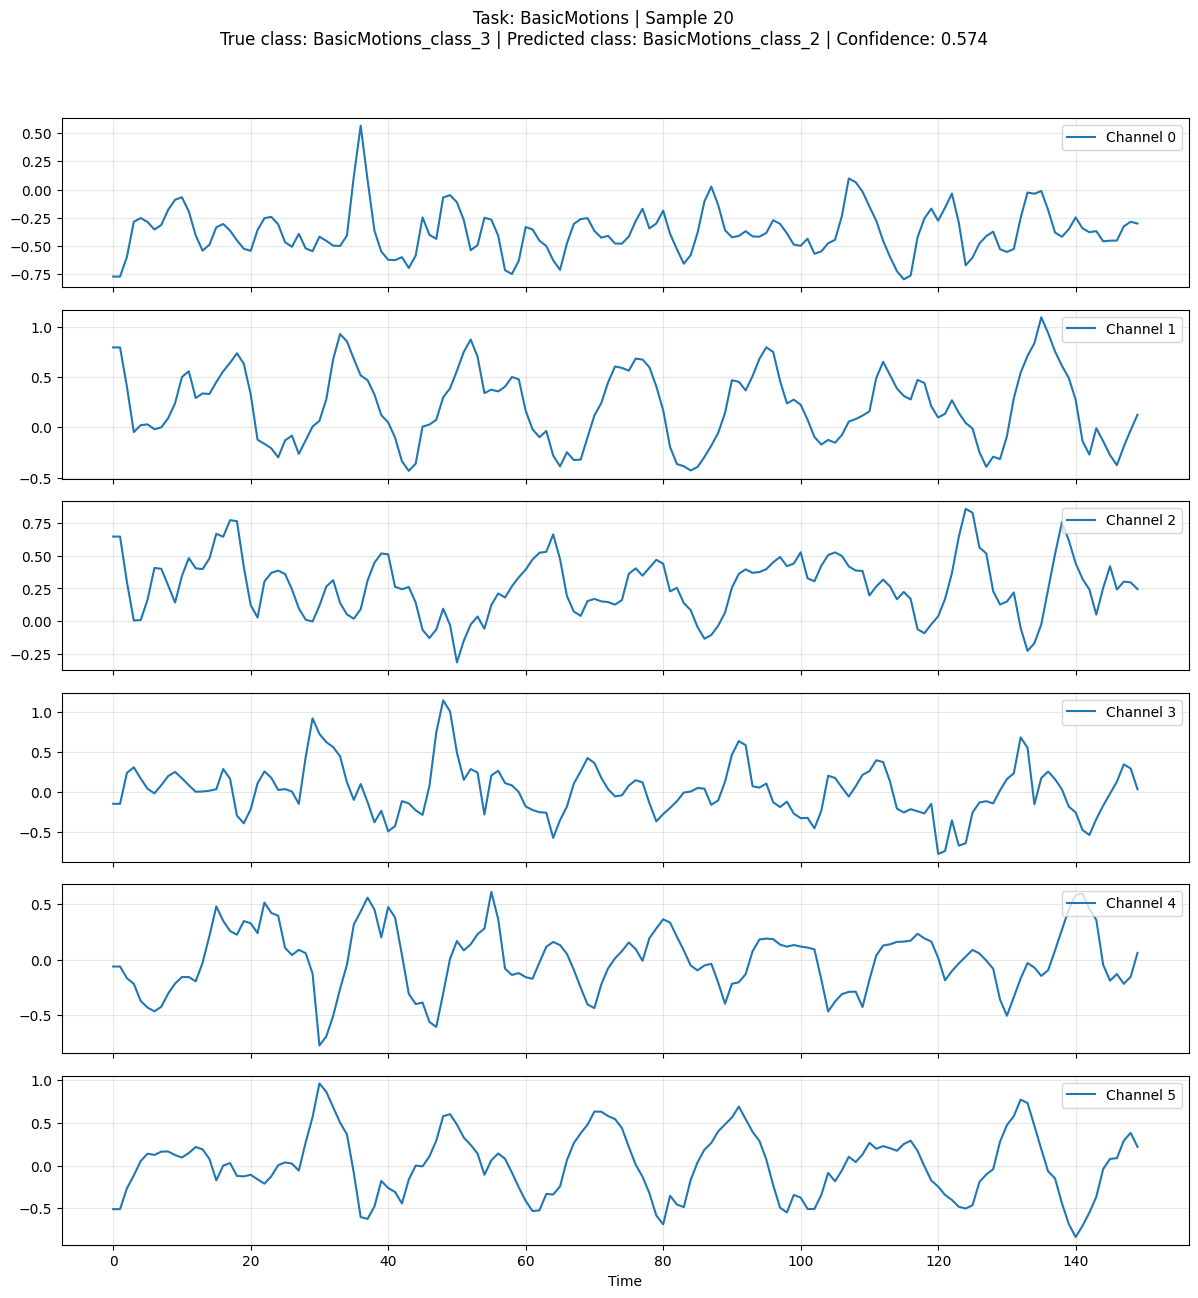

In [ ]:
# ============================================================
# 31) Show first misclassified sample
# ============================================================
def find_first_misclassified(strategy, task):
    strategy.model.eval()

    X_t = torch.tensor(task.X_test, dtype=torch.float32).to(strategy.device)
    with torch.no_grad():
        logits = strategy.model(X_t)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    wrong = np.where(preds != task.y_test)[0]
    if len(wrong) == 0:
        print("No misclassified samples found.")
        return None
    return int(wrong[0])

mis_idx = find_first_misclassified(baseline, tasks[0])
print("First misclassified index:", mis_idx)

if mis_idx is not None:
    visualize_multivariate_prediction(baseline, tasks[0], sample_idx=mis_idx, class_id_to_name=class_map)